In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12,6)

fund_master = pd.read_csv("../data/processed/clean_fund_master.csv")
nav = pd.read_csv("../data/processed/clean_nav.csv")
transactions = pd.read_csv("../data/processed/clean_transactions.csv")
portfolio = pd.read_csv("../data/processed/clean_portfolio_holdings.csv")
performance = pd.read_csv("../data/processed/clean_performance.csv")

nav["date"] = pd.to_datetime(nav["date"])
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

# Task 1: Historical VaR and CVaR

In [4]:
returns = nav.sort_values(
    ["amfi_code","date"]
)

returns["daily_return"] = (
    returns.groupby("amfi_code")["nav"]
    .pct_change()
)

results=[]

for fund,grp in returns.groupby("amfi_code"):

    r = grp["daily_return"].dropna()

    var95 = np.percentile(r,5)

    cvar95 = r[r<=var95].mean()

    results.append([
        fund,
        var95,
        cvar95
    ])

var_cvar = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


# Task 2: Rolling 90 Day Sharpe Ratio

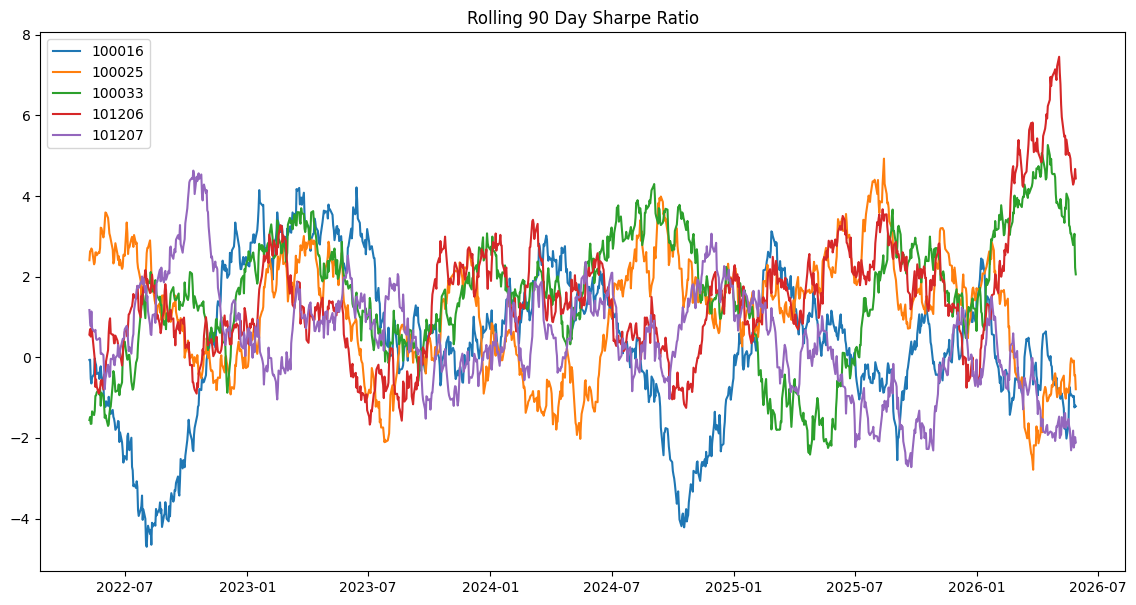

In [5]:
top5 = returns["amfi_code"].unique()[:5]

plt.figure(figsize=(14,7))

for fund in top5:

    temp = returns[
        returns["amfi_code"]==fund
    ].copy()

    rolling_sharpe = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.title(
    "Rolling 90 Day Sharpe Ratio"
)

plt.legend()

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

# Task 3: Investor Cohort Analysis

In [6]:
first_txn = (
    transactions
    .groupby("investor_id")
    ["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort"] = (
    first_txn["transaction_date"]
    .dt.year
)

transactions = transactions.merge(
    first_txn[
        ["investor_id","cohort"]
    ],
    on="investor_id"
)

cohort = (
    transactions
    .groupby("cohort")
    .agg(
        avg_sip_amount=
        ("amount_inr","mean"),

        total_invested=
        ("amount_inr","sum")
    )
    .reset_index()
)

cohort.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

cohort

,cohort,avg_sip_amount,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


# Task 4: SIP Continuity Analysis

In [7]:
sip = transactions[
    transactions["transaction_type"]
    == "SIP"
].copy()

sip = sip.sort_values(
    ["investor_id",
     "transaction_date"]
)

sip["gap"] = (
    sip.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

continuity = (
    sip.groupby("investor_id")
    .agg(
        sip_count=("gap","count"),
        avg_gap=("gap","mean")
    )
)

continuity = continuity[
    continuity["sip_count"]>=6
]

continuity["status"] = np.where(
    continuity["avg_gap"]>35,
    "At Risk",
    "Healthy"
)

continuity.to_csv(
    "../reports/sip_continuity.csv"
)

continuity.head()

,sip_count,avg_gap,status
investor_id,,,


# Task 6: Sector Concentration Analysis (HHI)

In [13]:
portfolio["weight_sq"] = (
    portfolio["weight_pct"]**2
)

hhi = (
    portfolio
    .groupby("amfi_code")
    ["weight_sq"]
    .sum()
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.to_csv(
    "../reports/sector_hhi.csv",
    index=False
)

hhi.head()

,amfi_code,HHI
0,100016,1395.3386
1,100033,1475.9226
2,101206,1293.3173
3,101207,2007.0043
4,102885,1747.0902


# Task 6 Chart

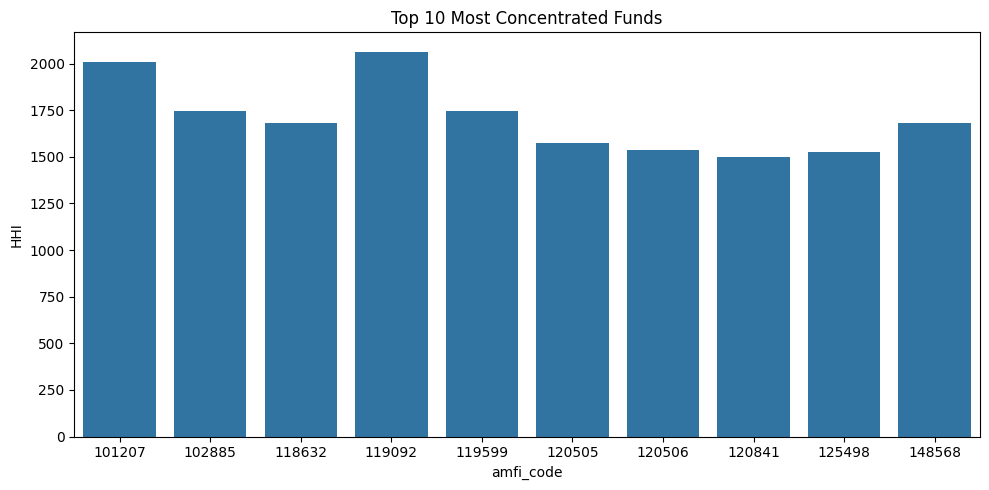

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

top_hhi = (
    sector_hhi
    .sort_values(
        "HHI",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_hhi,
    x="amfi_code",
    y="HHI"
)

plt.title(
    "Top 10 Most Concentrated Funds"
)

plt.tight_layout()

plt.show()

# Advanced Analytics Findings

1. Funds with the highest VaR exhibit significantly greater downside risk during volatile periods.

2. CVaR values indicate that extreme losses can exceed normal daily fluctuations by a large margin.

3. Investor cohorts entering in recent years contributed the highest total investment amounts.

4. A subset of SIP investors show average transaction gaps above 35 days and are classified as at-risk.

5. Funds with high Sharpe ratios consistently dominate recommendation results for their respective risk categories.